# 03 — Eksperimenti sa treniranjem modela

Cilj je da pronađemo najbolje vrednosti za **batch size, learning rate i temperature**.

Koristimo postojeće `train.pt` i `validation.pt`. `test.pt` se ne koristi za izbor hiperparametara.

Prvo radimo kratak screening svih kombinacija, a zatim najbolje konfiguracije treniramo 30 epoha.


In [1]:
from pathlib import Path
import itertools
import json
import random

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from vision_language_clothing_retrieval.retrieval.embedding_dataset import EmbeddingDataset
from vision_language_clothing_retrieval.retrieval.model import MultimodalModel
from vision_language_clothing_retrieval.retrieval.trainer import MultimodalTrainer

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

TRAIN_PATH = ROOT / "embeddings/train.pt"
VAL_PATH = ROOT / "embeddings/validation.pt"
RESULTS_DIR = ROOT / "embeddings/experiments"
RESULTS_DIR.mkdir(exist_ok=True)

DEVICE = "cpu"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_data = torch.load(TRAIN_PATH, weights_only=True)
val_data = torch.load(VAL_PATH, weights_only=True)

train_dataset = EmbeddingDataset(train_data)
val_dataset = EmbeddingDataset(val_data)

print("Broj uzoraka za treniranje:", len(train_dataset))
print("Broj uzoraka za validaciju:", len(val_dataset))


Broj uzoraka za treniranje: 34028
Broj uzoraka za validaciju: 4337


## 1. Grid Search

Definišemo samo skup mogućih vrednosti. `GridSearch` sam pravi sve kombinacije i testira ih.

Koristimo:

- batch size: `16, 32`
- learning rate: `0.001, 0.003, 0.005`
- temperature: `0.07, 0.1, 0.15`

Ukupno: **18 kombinacija**.


In [2]:
class GridSearch:
    def __init__(self, param_grid, epochs=5):
        self.param_grid = param_grid
        self.epochs = epochs
        self.results = []

    def fit(self):
        keys = list(self.param_grid)
        values = [self.param_grid[k] for k in keys]

        for params in itertools.product(*values):
            config = dict(zip(keys, params))

            torch.manual_seed(SEED)

            train_loader = DataLoader(
                train_dataset,
                batch_size=config["batch_size"],
                shuffle=True,
            )
            val_loader = DataLoader(
                val_dataset,
                batch_size=config["batch_size"],
                shuffle=False,
            )

            model = MultimodalModel()
            trainer = MultimodalTrainer(
                model=model,
                learning_rate=config["learning_rate"],
                temperature=config["temperature"],
            )

            best_val_loss = float("inf")

            for epoch in range(self.epochs):
                trainer.train_epoch(train_loader, DEVICE)
                val_loss = trainer.evaluate_epoch(val_loader, DEVICE)
                best_val_loss = min(best_val_loss, val_loss)

            result = {**config, "best_val_loss": best_val_loss}
            self.results.append(result)

            print("Konfiguracija:", config, "-> najbolji validation loss:", round(best_val_loss, 4))

        return self

    def results_table(self):
        return pd.DataFrame(self.results).sort_values(
            "best_val_loss"
        ).reset_index(drop=True)


In [3]:
param_grid = {
    "batch_size": [16, 32],
    "learning_rate": [0.001, 0.003, 0.005],
    "temperature": [0.07, 0.1, 0.15],
}

grid_search = GridSearch(
    param_grid=param_grid,
    epochs=5,
)

grid_search.fit()


Konfiguracija: {'batch_size': 16, 'learning_rate': 0.001, 'temperature': 0.07} -> najbolji validation loss: 2.2663
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.001, 'temperature': 0.1} -> najbolji validation loss: 2.2539
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.001, 'temperature': 0.15} -> najbolji validation loss: 2.253
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.003, 'temperature': 0.07} -> najbolji validation loss: 2.2747
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.003, 'temperature': 0.1} -> najbolji validation loss: 2.2715
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.003, 'temperature': 0.15} -> najbolji validation loss: 2.2734
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.005, 'temperature': 0.07} -> najbolji validation loss: 2.2737
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.005, 'temperature': 0.1} -> najbolji validation loss: 2.2615
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.005, 'temperature': 0.15} -> na

In [4]:
screening_results = grid_search.results_table()
screening_results


,batch_size,learning_rate,temperature,best_val_loss
0,16,0.001,0.15,2.252977
1,16,0.001,0.10,2.253902
2,16,0.005,0.15,2.258791
3,16,0.005,0.10,2.261513
4,16,0.001,0.07,2.266323
5,16,0.003,0.10,2.271534
6,16,0.003,0.15,2.273381
7,16,0.005,0.07,2.273724
8,16,0.003,0.07,2.274707
9,32,0.001,0.07,2.853651


In [5]:
screening_results.to_csv(
    RESULTS_DIR / "grid_search_results.csv",
    index=False,
)

with open(RESULTS_DIR / "grid_search_results.json", "w") as f:
    json.dump(grid_search.results, f, indent=2)

print("Rezultati su sačuvani u:", RESULTS_DIR)


Rezultati su sačuvani u: C:\Users\milic\OneDrive\Desktop\Visual language clothing retrieval\Vision-language-clothing-retrieval\embeddings\experiments


## 2. Izbor najboljih konfiguracija

Screening koristimo samo da pronađemo najperspektivnije konfiguracije.

Uzimamo **3 najbolje**, a njih zatim ponovo treniramo od početka tokom 30 epoha.


In [6]:
top_candidates = screening_results.head(3)
top_candidates


,batch_size,learning_rate,temperature,best_val_loss
0,16,0.001,0.15,2.252977
1,16,0.001,0.10,2.253902
2,16,0.005,0.15,2.258791


In [7]:
def train_candidate(config, epochs=30):
    torch.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=int(config["batch_size"]),
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=int(config["batch_size"]),
        shuffle=False,
    )

    model = MultimodalModel()
    trainer = MultimodalTrainer(
        model=model,
        learning_rate=float(config["learning_rate"]),
        temperature=float(config["temperature"]),
    )

    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        train_loss = trainer.train_epoch(train_loader, DEVICE)
        val_loss = trainer.evaluate_epoch(val_loader, DEVICE)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"Epoha {epoch}/{epochs} - "
            f"greška na train skupu: {train_loss:.4f} - "
            f"greška na validation skupu: {val_loss:.4f}"
        )

    return best_val_loss, best_epoch, best_state, history


In [8]:
final_results = []

for i, (_, row) in enumerate(top_candidates.iterrows(), start=1):
    config = {
        "batch_size": int(row["batch_size"]),
        "learning_rate": float(row["learning_rate"]),
        "temperature": float(row["temperature"]),
    }

    print("\nKandidat", i, config)

    best_loss, best_epoch, state, history = train_candidate(config)

    model_path = RESULTS_DIR / f"candidate_{i}.pt"
    torch.save(state, model_path)

    final_results.append({
        **config,
        "best_val_loss": best_loss,
        "best_epoch": best_epoch,
        "model_path": str(model_path),
        "history": history,
    })



Kandidat 1 {'batch_size': 16, 'learning_rate': 0.001, 'temperature': 0.15}
Epoha 1/30 - greška na train skupu: 2.5887 - greška na validation skupu: 2.4937
Epoha 2/30 - greška na train skupu: 2.3082 - greška na validation skupu: 2.4336
Epoha 3/30 - greška na train skupu: 2.2007 - greška na validation skupu: 2.2765
Epoha 4/30 - greška na train skupu: 2.1336 - greška na validation skupu: 2.3596
Epoha 5/30 - greška na train skupu: 2.0989 - greška na validation skupu: 2.2530
Epoha 6/30 - greška na train skupu: 2.0435 - greška na validation skupu: 2.3013
Epoha 7/30 - greška na train skupu: 2.0141 - greška na validation skupu: 2.1784
Epoha 8/30 - greška na train skupu: 1.9935 - greška na validation skupu: 2.2684
Epoha 9/30 - greška na train skupu: 1.9598 - greška na validation skupu: 2.2124
Epoha 10/30 - greška na train skupu: 1.9425 - greška na validation skupu: 2.2299
Epoha 11/30 - greška na train skupu: 1.9236 - greška na validation skupu: 2.1815
Epoha 12/30 - greška na train skupu: 1.910

In [9]:
final_results = pd.DataFrame(final_results).sort_values(
    "best_val_loss"
).reset_index(drop=True)

final_results


,batch_size,learning_rate,temperature,best_val_loss,best_epoch,model_path,history
0,16,0.005,0.15,2.066685,26,C:\Users\milic\OneDrive\Desktop\Visual languag...,"[{'epoch': 1, 'train_loss': 2.604639001670554,..."
1,16,0.001,0.15,2.072854,26,C:\Users\milic\OneDrive\Desktop\Visual languag...,"[{'epoch': 1, 'train_loss': 2.5887439278968913..."
2,16,0.001,0.10,2.072983,26,C:\Users\milic\OneDrive\Desktop\Visual languag...,"[{'epoch': 1, 'train_loss': 2.5641107068803874..."


## 3. Evaluacija retrieval performansi na validation skupu

Validation loss koristimo za praćenje toka treniranja, ali konačan izbor modela zasnivamo na retrieval metrikama.

Za baseline i tri najbolje konfiguracije računamo:
- Recall@1
- Recall@5
- Recall@10
- MRR
- Mean Rank

Evaluacija se radi na `validation.pt` skupu. `test.pt` se ne koristi za izbor modela i ostaje samo za konačnu evaluaciju.


In [10]:
from vision_language_clothing_retrieval.retrieval.multimodal_retriever import (
    MultimodalRetriever,
)
from vision_language_clothing_retrieval.evaluation.text_to_image.evaluator import (
    TextToImageEvaluator,
)
from vision_language_clothing_retrieval.evaluation.image_to_text.evaluator import (
    ImageToTextEvaluator,
)

validation_models = {
    "Baseline": ROOT / "embeddings/multimodal_model.pt",
}

for i in range(1, 4):
    validation_models[f"Candidate {i}"] = RESULTS_DIR / f"candidate_{i}.pt"

validation_results = []

for model_name, model_path in validation_models.items():
    print(f"Evaluacija: {model_name}")

    retriever = MultimodalRetriever(model_path=str(model_path))

    text_to_image_evaluator = TextToImageEvaluator(
        retriever=retriever,
        image_embeddings=val_data["image_embeddings"],
        text_embeddings=val_data["text_embeddings"],
        sample_ids=val_data["sample_ids"],
    )

    image_to_text_evaluator = ImageToTextEvaluator(
        retriever=retriever,
        image_embeddings=val_data["image_embeddings"],
        text_embeddings=val_data["text_embeddings"],
        sample_ids=val_data["sample_ids"],
    )

    text_to_image_metrics = text_to_image_evaluator.evaluate()
    image_to_text_metrics = image_to_text_evaluator.evaluate(k_values=(1, 5, 10))

    validation_results.append({
        "model": model_name,
        "text_to_image_recall_at_1": text_to_image_metrics["recall@1"],
        "text_to_image_recall_at_5": text_to_image_metrics["recall@5"],
        "text_to_image_recall_at_10": text_to_image_metrics["recall@10"],
        "text_to_image_mrr": text_to_image_metrics["mrr"],
        "text_to_image_mean_rank": text_to_image_metrics["mean_rank"],
        "image_to_text_recall_at_1": image_to_text_metrics["recall@1"],
        "image_to_text_recall_at_5": image_to_text_metrics["recall@5"],
        "image_to_text_recall_at_10": image_to_text_metrics["recall@10"],
        "image_to_text_mrr": image_to_text_metrics["mrr"],
        "image_to_text_mean_rank": image_to_text_metrics["mean_rank"],
    })

validation_results = pd.DataFrame(validation_results)
validation_results


Evaluacija: Baseline
Evaluacija: Candidate 1
Evaluacija: Candidate 2
Evaluacija: Candidate 3


,model,text_to_image_recall_at_1,text_to_image_recall_at_5,text_to_image_recall_at_10,text_to_image_mrr,text_to_image_mean_rank,image_to_text_recall_at_1,image_to_text_recall_at_5,image_to_text_recall_at_10,image_to_text_mrr,image_to_text_mean_rank
0,Baseline,0.036661,0.122435,0.199908,0.092452,186.063177,0.029744,0.098225,0.146415,0.072776,247.141803
1,Candidate 1,0.040120,0.120129,0.177081,0.090158,205.938898,0.022596,0.083237,0.138344,0.064169,270.059949
2,Candidate 2,0.041273,0.121051,0.178926,0.091537,200.116671,0.026285,0.085312,0.141803,0.067426,266.505649
3,Candidate 3,0.037814,0.117132,0.181231,0.088499,203.871570,0.022366,0.089924,0.138575,0.065529,265.776113


### Poređenje modela na validation skupu

Baseline uključujemo kao referentnu vrednost. Kandidati se porede sa baseline modelom pomoću retrieval metrika.


In [11]:
validation_results


,model,text_to_image_recall_at_1,text_to_image_recall_at_5,text_to_image_recall_at_10,text_to_image_mrr,text_to_image_mean_rank,image_to_text_recall_at_1,image_to_text_recall_at_5,image_to_text_recall_at_10,image_to_text_mrr,image_to_text_mean_rank
0,Baseline,0.036661,0.122435,0.199908,0.092452,186.063177,0.029744,0.098225,0.146415,0.072776,247.141803
1,Candidate 1,0.040120,0.120129,0.177081,0.090158,205.938898,0.022596,0.083237,0.138344,0.064169,270.059949
2,Candidate 2,0.041273,0.121051,0.178926,0.091537,200.116671,0.026285,0.085312,0.141803,0.067426,266.505649
3,Candidate 3,0.037814,0.117132,0.181231,0.088499,203.871570,0.022366,0.089924,0.138575,0.065529,265.776113


## 4. Konačan izbor modela

Model biramo na osnovu retrieval performansi na validation skupu, a ne samo na osnovu validation loss-a.

Kao glavni kriterijum koristimo MRR za oba pravca pretrage, uz Recall@10 kao dodatnu proveru kvaliteta rezultata.


In [12]:
validation_results["average_mrr"] = (
    validation_results["text_to_image_mrr"]
    + validation_results["image_to_text_mrr"]
) / 2

validation_results["average_recall_at_10"] = (
    validation_results["text_to_image_recall_at_10"]
    + validation_results["image_to_text_recall_at_10"]
) / 2

validation_results = validation_results.sort_values(
    ["average_mrr", "average_recall_at_10"],
    ascending=False,
).reset_index(drop=True)

best_model = validation_results.iloc[0]

print("Izabrani model:", best_model["model"])
print("Prosečan MRR:", round(best_model["average_mrr"], 4))
print("Prosečan Recall@10:", round(best_model["average_recall_at_10"], 4))

validation_results


Izabrani model: Baseline
Prosečan MRR: 0.0826
Prosečan Recall@10: 0.1732


,model,text_to_image_recall_at_1,text_to_image_recall_at_5,text_to_image_recall_at_10,text_to_image_mrr,text_to_image_mean_rank,image_to_text_recall_at_1,image_to_text_recall_at_5,image_to_text_recall_at_10,image_to_text_mrr,image_to_text_mean_rank,average_mrr,average_recall_at_10
0,Baseline,0.036661,0.122435,0.199908,0.092452,186.063177,0.029744,0.098225,0.146415,0.072776,247.141803,0.082614,0.173161
1,Candidate 2,0.041273,0.121051,0.178926,0.091537,200.116671,0.026285,0.085312,0.141803,0.067426,266.505649,0.079481,0.160364
2,Candidate 1,0.040120,0.120129,0.177081,0.090158,205.938898,0.022596,0.083237,0.138344,0.064169,270.059949,0.077163,0.157713
3,Candidate 3,0.037814,0.117132,0.181231,0.088499,203.871570,0.022366,0.089924,0.138575,0.065529,265.776113,0.077014,0.159903


In [13]:
validation_results.to_csv(
    RESULTS_DIR / "validation_retrieval_results.csv",
    index=False,
)


In [14]:
print("Izabrani model za finalnu evaluaciju:")
print("model:", best_model["model"])

if best_model["model"] != "Baseline":
    candidate_number = int(best_model["model"].split()[-1])
    selected_config = final_results[
        final_results["model_path"].str.contains(f"candidate_{candidate_number}.pt")
    ].iloc[0]

    print("veličina batch-a:", int(selected_config["batch_size"]))
    print("learning rate:", selected_config["learning_rate"])
    print("temperature:", selected_config["temperature"])
    print("najmanja greška na validaciji:", round(selected_config["best_val_loss"], 4))
    print("najbolja epoha po validation loss-u:", int(selected_config["best_epoch"]))
    print("model:", selected_config["model_path"])
else:
    print("Baseline model se zadržava kao najbolji model prema validation retrieval metrikama.")


Izabrani model za finalnu evaluaciju:
model: Baseline
Baseline model se zadržava kao najbolji model prema validation retrieval metrikama.


In [15]:
final_results.to_csv(
    RESULTS_DIR / "final_experiment_results.csv",
    index=False,
)

validation_results.to_csv(
    RESULTS_DIR / "validation_retrieval_results.csv",
    index=False,
)


### Analiza toka treniranja

Za najbolje konfiguracije prikazujemo promenu greške na skupu za treniranje i validation skupu kroz epohe.

Grafici služe za praćenje toka treniranja i uočavanje eventualnog overfitting-a. Izbor konačnog modela se ipak zasniva na retrieval performansama na validation skupu.


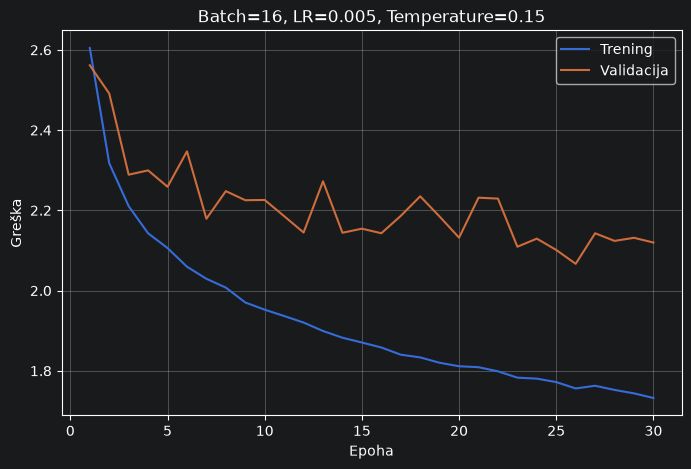

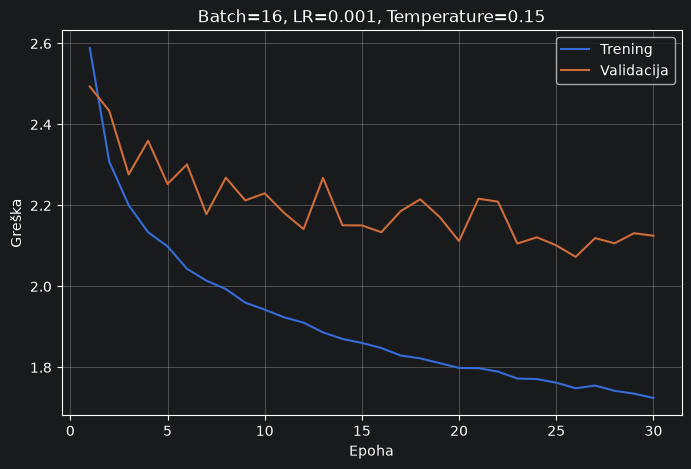

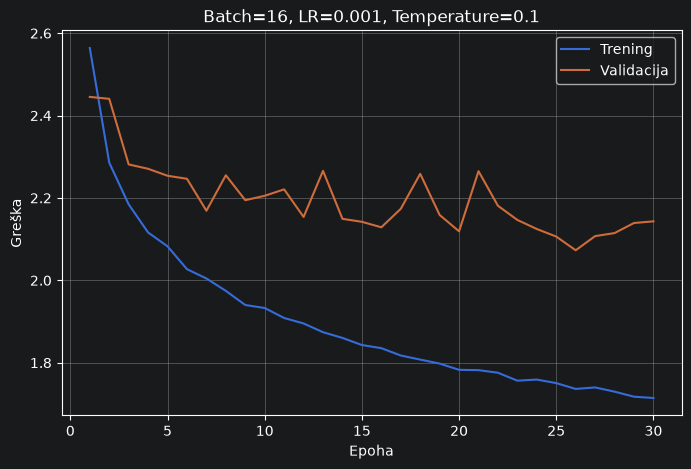

In [16]:
import matplotlib.pyplot as plt

for _, result in final_results.iterrows():
    history = pd.DataFrame(result["history"])

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["epoch"],
        history["train_loss"],
        label="Trening"
    )

    plt.plot(
        history["epoch"],
        history["val_loss"],
        label="Validacija"
    )

    plt.xlabel("Epoha")
    plt.ylabel("Greška")
    plt.title(
        f"Batch={int(result['batch_size'])}, "
        f"LR={result['learning_rate']}, "
        f"Temperature={result['temperature']}"
    )

    plt.legend()
    plt.grid()
    plt.show()

## Zaključak

Na osnovu retrieval rezultata na validation skupu izabrana je konfiguracija koja daje najbolje performanse za zadatak pretrage.

Validation loss ostaje važan za praćenje toka treniranja, ali nije jedini kriterijum za izbor modela. Konačan izbor zasnivamo na retrieval metrikama za oba pravca:
- Text → Image
- Image → Text

Izabrani model će u sledećem koraku biti evaluiran na `test.pt` skupu.

Za konačnu evaluaciju koristićemo:
- Recall@1
- Recall@5
- Recall@10
- MRR
- Mean Rank
